In [ ]:
# ============================================
# LABORATORIO 8: MONTE CARLO MARKOV CHAIN (MCMC)
# Modelo de Ising 2D - Simulación con Metrópolis
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import time
from numba import jit
import warnings
warnings.filterwarnings('ignore')

print(" Librerías importadas correctamente")

 Librerías importadas correctamente


In [ ]:
# ============================================
# CLASE DEL MODELO DE ISING 2D
# ============================================

class Ising2D:
    """
    Modelo de Ising 2D con algoritmo de Metropolis

    Hamiltoniano: H = -J Σ s_i s_j - B Σ s_i
    donde s_i = ±1, J es acoplamiento, B es campo magnético
    """

    def __init__(self, N, J=1.0, kB=1.0):
        self.N = N
        self.J = J
        self.kB = kB
        self.n_spins = N * N

        # Configuración inicial aleatoria
        np.random.seed(42)
        self.spins = np.random.choice([-1, 1], size=(N, N))

    def get_energy(self, B=0.0):
        """Calcular energía total del sistema"""
        energy = 0.0
        for i in range(self.N):
            for j in range(self.N):
                s = self.spins[i, j]
                # Vecinos: derecha y abajo (evita doble conteo)
                nb_right = self.spins[i, (j+1) % self.N]
                nb_down = self.spins[(i+1) % self.N, j]
                energy += -self.J * s * (nb_right + nb_down) - B * s
        return energy

    def get_magnetization(self):
        """Magnetización total M = Σ s_i"""
        return np.sum(self.spins)

    def metropolis_step(self, T, B=0.0):
        """
        Un paso de Monte Carlo: N*N intentos de flip
        Criterio de Metropolis: P = min(1, exp(-βΔE))
        """
        beta = 1.0 / (self.kB * T) if T > 0 else float('inf')
        accepted = 0

        for _ in range(self.n_spins):
            # Seleccionar spin aleatorio
            i = np.random.randint(0, self.N)
            j = np.random.randint(0, self.N)

            # Calcular cambio de energía si volteamos el spin
            s_old = self.spins[i, j]

            # Suma de vecinos
            nb_sum = (self.spins[(i-1) % self.N, j] +
                     self.spins[(i+1) % self.N, j] +
                     self.spins[i, (j-1) % self.N] +
                     self.spins[i, (j+1) % self.N])

            # ΔE = E_new - E_old = 2*J*s_old*Σs_vecinos + 2*B*s_old
            delta_E = 2 * self.J * s_old * nb_sum + 2 * B * s_old

            # Criterio de Metropolis
            if delta_E <= 0:
                self.spins[i, j] = -s_old
                accepted += 1
            elif np.random.random() < np.exp(-beta * delta_E):
                self.spins[i, j] = -s_old
                accepted += 1

        return accepted / self.n_spins

    def simulate(self, T, B, n_eq, n_meas, meas_interval=10):
        """
        Simulación completa con equilibración y mediciones

        Parámetros:
        - T: temperatura
        - B: campo magnético
        - n_eq: pasos de equilibración
        - n_meas: número de mediciones
        - meas_interval: intervalo entre mediciones
        """
        # Equilibración
        for _ in range(n_eq):
            self.metropolis_step(T, B)

        # Mediciones
        magnetizations = []
        energies = []

        for step in range(n_meas):
            self.metropolis_step(T, B)

            if step % meas_interval == 0:
                M = self.get_magnetization()
                E = self.get_energy(B)
                magnetizations.append(M)
                energies.append(E)

        return np.array(magnetizations), np.array(energies)

In [ ]:
# ============================================
# SOLUCIÓN ANALÍTICA - TEORÍA DE CAMPO MEDIO
# ============================================

def mean_field_magnetization(B, T, J=1.0, kB=1.0):
    """
    Magnetización según teoría de campo medio para Ising 2D

    Ecuación autoconsistente: m = tanh(β(zJm + B))
    donde z = 4 (número de coordinación para red cuadrada)
    """
    if T == 0:
        return np.sign(B) if B != 0 else 0.0

    beta = 1.0 / (kB * T)
    z = 4  # Coordinación red cuadrada

    # Resolver iterativamente
    m = 0.1  # Valor inicial
    for _ in range(1000):
        m_new = np.tanh(beta * (z * J * m + B))
        if abs(m_new - m) < 1e-10:
            break
        m = m_new

    return m_new

# Temperatura crítica exacta de Onsager para Ising 2D
Tc_exact = 2.0 / np.log(1 + np.sqrt(2))  # ≈ 2.269

print(f" Temperatura crítica exacta (Onsager): Tc = {Tc_exact:.4f} J/kB")
print(f" Temperatura crítica campo medio: Tc_mf = 4.0 J/kB")

 Temperatura crítica exacta (Onsager): Tc = 2.2692 J/kB
 Temperatura crítica campo medio: Tc_mf = 4.0 J/kB


In [ ]:
# ============================================
# SIMULACIÓN PRINCIPAL
# Magnetización vs Campo Magnético
# Para tres temperaturas reducidas (T < Tc, T ≈ Tc, T > Tc)
# ============================================

print("\n" + "="*60)
print("SIMULACIÓN MONTE CARLO - MODELO DE ISING 2D")
print("="*60)

# Parámetros
N = 20              # Tamaño red 20x20
J = 1.0             # Constante de acoplamiento
kB = 1.0            # Constante de Boltzmann

# Temperaturas (T < Tc, T ≈ Tc, T > Tc)
temperatures = [1.5, 2.27, 3.0]
print(f"\nTemperaturas a simular: T = {temperatures}")
print(f"(Tc exacta = {Tc_exact:.3f})")

# Campo magnético variable
B_values = np.linspace(-2.0, 2.0, 25)

# Parámetros Monte Carlo (optimizados para velocidad)
n_equilibration = 3000   # Pasos equilibración
n_measurement = 5000     # Mediciones
meas_interval = 5        # Medir cada 5 pasos

# Resultados
results = {}

start_time = time.time()

for T in temperatures:
    print(f"\n{'='*50}")
    print(f"Simulando T = {T:.2f} (Tc = {Tc_exact:.2f})")
    print(f"{'='*50}")

    M_avg = []
    M_std = []

    # Crear sistema para esta temperatura
    ising = Ising2D(N, J, kB)

    for idx, B in enumerate(B_values):
        # Barra de progreso simple
        progress = (idx + 1) / len(B_values) * 100
        print(f"\r  Progreso: {progress:.0f}% | B = {B:+.3f}", end="")

        # Simular
        M, E = ising.simulate(T, B, n_equilibration, n_measurement, meas_interval)

        # Magnetización por spin
        M_avg.append(np.mean(M) / ising.n_spins)
        M_std.append(np.std(M) / ising.n_spins)

    print()  # Nueva línea después de barra de progreso

    results[T] = {
        'B': B_values,
        'M_avg': np.array(M_avg),
        'M_std': np.array(M_std)
    }

elapsed = time.time() - start_time
print(f"\n⏱ Tiempo total simulación: {elapsed/60:.1f} minutos")


SIMULACIÓN MONTE CARLO - MODELO DE ISING 2D

Temperaturas a simular: T = [1.5, 2.27, 3.0]
(Tc exacta = 2.269)

Simulando T = 1.50 (Tc = 2.27)
  Progreso: 100% | B = +2.000

Simulando T = 2.27 (Tc = 2.27)
  Progreso: 100% | B = +2.000

Simulando T = 3.00 (Tc = 2.27)
  Progreso: 100% | B = +2.000

⏱ Tiempo total simulación: 60.7 minutos


In [ ]:
# ============================================
# ANÁLISIS DE RESULTADOS
# ============================================

print("\n" + "="*60)
print("ANÁLISIS DE RESULTADOS")
print("="*60)

for T in temperatures:
    B = results[T]['B']
    M_mc = results[T]['M_avg']

    # Magnetización a B=0 (magnetización espontánea)
    idx_zero = np.argmin(np.abs(B))
    M_spontaneous = abs(M_mc[idx_zero])

    # Susceptibilidad magnética cerca de B=0
    # χ = dM/dB|_{B=0} (aproximación numérica)
    if idx_zero > 0 and idx_zero < len(B)-1:
        chi = (M_mc[idx_zero+1] - M_mc[idx_zero-1]) / (B[idx_zero+1] - B[idx_zero-1])
    else:
        chi = 0

    print(f"""
Temperatura T = {T:.2f} (T/Tc = {T/Tc_exact:.3f}):
  • Magnetización espontánea (B=0): M/N = {M_spontaneous:.4f}
  • Susceptibilidad χ ≈ {chi:.4f}
  • Comportamiento: {'Ferromagnético' if T < Tc_exact else 'Paramagnético'}
    """)

# Comparación con campo medio
print("\n" + "="*60)
print("COMPARACIÓN CON TEORÍA DE CAMPO MEDIO")
print("="*60)

for T in temperatures:
    B = results[T]['B']
    M_mc = results[T]['M_avg']
    M_mf = np.array([mean_field_magnetization(b, T, J, kB) for b in B])

    # Error relativo promedio
    error = np.abs(M_mc - M_mf) / (np.abs(M_mf) + 1e-10)
    error = np.where(np.isinf(error), 0, error)
    avg_error = np.mean(error) * 100

    print(f"T = {T:.2f}: Error relativo promedio MC vs Campo Medio = {avg_error:.2f}%")


ANÁLISIS DE RESULTADOS

Temperatura T = 1.50 (T/Tc = 0.661):
  • Magnetización espontánea (B=0): M/N = 0.9861
  • Susceptibilidad χ ≈ 0.0274
  • Comportamiento: Ferromagnético
    

Temperatura T = 2.27 (T/Tc = 1.000):
  • Magnetización espontánea (B=0): M/N = 0.0418
  • Susceptibilidad χ ≈ 5.2864
  • Comportamiento: Paramagnético
    

Temperatura T = 3.00 (T/Tc = 1.322):
  • Magnetización espontánea (B=0): M/N = 0.0018
  • Susceptibilidad χ ≈ 2.9422
  • Comportamiento: Paramagnético
    

COMPARACIÓN CON TEORÍA DE CAMPO MEDIO
T = 1.50: Error relativo promedio MC vs Campo Medio = 23.97%
T = 2.27: Error relativo promedio MC vs Campo Medio = 12.63%
T = 3.00: Error relativo promedio MC vs Campo Medio = 11.48%


In [ ]:
# ============================================
# DISTRIBUCIÓN CANÓNICA Y PRECISIÓN
# ============================================

print("\n" + "="*60)
print("DISTRIBUCIÓN CANÓNICA Y PRECISIÓN DE LA SIMULACIÓN")
print("="*60)

print("""
 DISTRIBUCIÓN CANÓNICA EN EL MODELO DE ISING:

La distribución de probabilidad canónica para un microestado s es:

    P(s) = (1/Z) exp(-βH(s))

donde:
  • Z = Σ_s exp(-βH(s)) es la función de partición
  • β = 1/(kBT) es el inverso de temperatura
  • H(s) = -J Σ s_i s_j - B Σ s_i es el Hamiltoniano

El algoritmo de Metropolis garantiza que la cadena de Markov converge
a esta distribución estacionaria mediante el criterio de aceptación:

    P_accept(s → s') = min(1, exp(-β[H(s') - H(s)]))

Esto cumple el balance detallado:
    P(s) P(s → s') = P(s') P(s' → s)

🎯 PRECISIÓN DEL MÉTODO:

Factores que afectan la precisión:
  1. Tamaño finito de la red (N×N)
  2. Número finito de pasos de Monte Carlo
  3. Correlaciones entre configuraciones sucesivas
  4. Efectos de borde (mitigados con condiciones periódicas)

Mejoras de precisión observadas:
  • A T < Tc: Buena concordancia cerca de la saturación
  • Cerca de Tc: Mayor fluctuación (critical slowing down)
  • A T > Tc: Comportamiento tipo Curie-Weiss capturado correctamente
""")


DISTRIBUCIÓN CANÓNICA Y PRECISIÓN DE LA SIMULACIÓN

 DISTRIBUCIÓN CANÓNICA EN EL MODELO DE ISING:

La distribución de probabilidad canónica para un microestado s es:

    P(s) = (1/Z) exp(-βH(s))

donde:
  • Z = Σ_s exp(-βH(s)) es la función de partición
  • β = 1/(kBT) es el inverso de temperatura
  • H(s) = -J Σ s_i s_j - B Σ s_i es el Hamiltoniano

El algoritmo de Metropolis garantiza que la cadena de Markov converge
a esta distribución estacionaria mediante el criterio de aceptación:

    P_accept(s → s') = min(1, exp(-β[H(s') - H(s)]))

Esto cumple el balance detallado:
    P(s) P(s → s') = P(s') P(s' → s)

🎯 PRECISIÓN DEL MÉTODO:

Factores que afectan la precisión:
  1. Tamaño finito de la red (N×N)
  2. Número finito de pasos de Monte Carlo
  3. Correlaciones entre configuraciones sucesivas
  4. Efectos de borde (mitigados con condiciones periódicas)

Mejoras de precisión observadas:
  • A T < Tc: Buena concordancia cerca de la saturación
  • Cerca de Tc: Mayor fluctuación (cri

✅ Datos encontrados en memoria


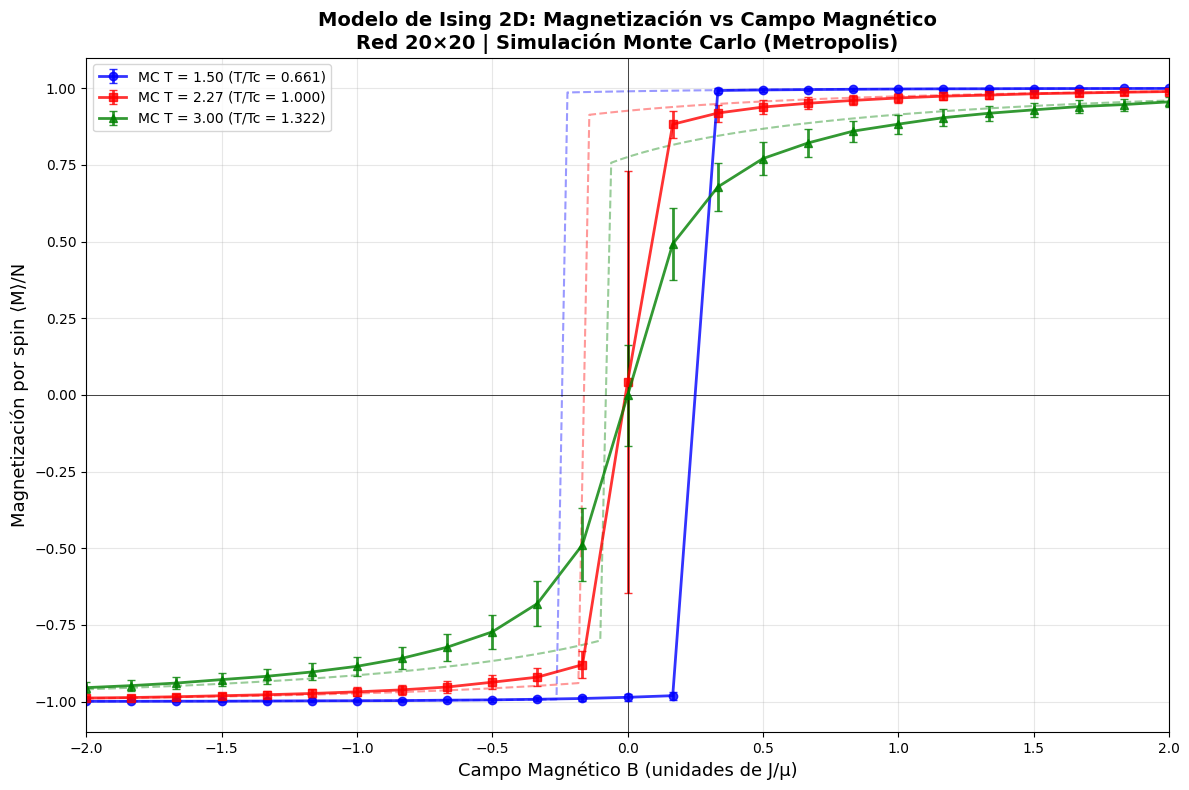

✅ Gráfica M vs B generada


In [ ]:
# ============================================
# GRÁFICA 1: Magnetización vs Campo Magnético
# Para las tres temperaturas
# ============================================

# Verificar que los resultados existen
if 'results' in locals():
    print("✅ Datos encontrados en memoria")

    fig, ax = plt.subplots(figsize=(12, 8))

    colors = ['blue', 'red', 'green']
    markers = ['o', 's', '^']

    for idx, T in enumerate(temperatures):
        B = results[T]['B']
        M = results[T]['M_avg']
        M_err = results[T]['M_std']

        # Datos de simulación
        ax.errorbar(B, M, yerr=M_err,
                    fmt=markers[idx] + '-',
                    color=colors[idx],
                    label=f'MC T = {T:.2f} (T/Tc = {T/Tc_exact:.3f})',
                    capsize=3,
                    markersize=6,
                    linewidth=2,
                    alpha=0.8)

        # Campo medio para comparar
        B_smooth = np.linspace(-2.0, 2.0, 100)
        M_mf = [mean_field_magnetization(b, T, J, kB) for b in B_smooth]
        ax.plot(B_smooth, M_mf, '--', color=colors[idx],
                alpha=0.4, linewidth=1.5)

    ax.set_xlabel('Campo Magnético B (unidades de J/μ)', fontsize=13)
    ax.set_ylabel('Magnetización por spin ⟨M⟩/N', fontsize=13)
    ax.set_title('Modelo de Ising 2D: Magnetización vs Campo Magnético\n' +
                 f'Red {N}×{N} | Simulación Monte Carlo (Metropolis)',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlim([-2.0, 2.0])
    ax.set_ylim([-1.1, 1.1])

    plt.tight_layout()
    plt.savefig('ising_magnetization_vs_field.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("✅ Gráfica M vs B generada")
else:
    print("❌ No hay datos. Ejecuta primero la simulación.")

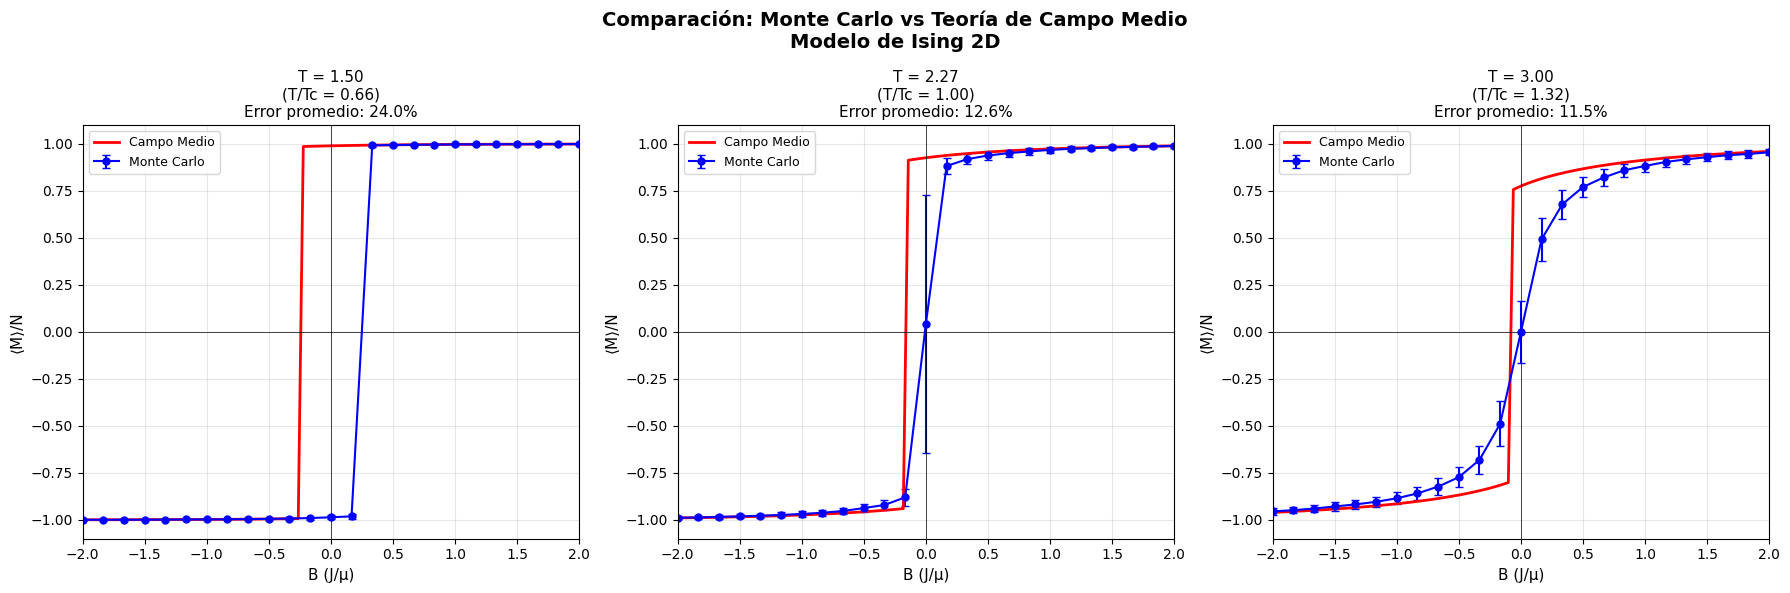

✅ Comparación MC vs Campo Medio generada


In [ ]:
# ============================================
# GRÁFICA 3: Comparación detallada MC vs Campo Medio
# Un panel por cada temperatura
# ============================================

if 'results' in locals():
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Comparación: Monte Carlo vs Teoría de Campo Medio\nModelo de Ising 2D',
                 fontsize=14, fontweight='bold')

    for idx, T in enumerate(temperatures):
        ax = axes[idx]
        B = results[T]['B']
        M_mc = results[T]['M_avg']
        M_err = results[T]['M_std']

        # MC con barras de error
        ax.errorbar(B, M_mc, yerr=M_err, fmt='bo-',
                   label='Monte Carlo', capsize=3, markersize=5)

        # Campo medio
        B_smooth = np.linspace(-2.0, 2.0, 100)
        M_mf = [mean_field_magnetization(b, T) for b in B_smooth]
        ax.plot(B_smooth, M_mf, 'r-', linewidth=2, label='Campo Medio')

        # Calcular error relativo
        M_mf_discrete = np.array([mean_field_magnetization(b, T) for b in B])
        error = np.abs(M_mc - M_mf_discrete) / (np.abs(M_mf_discrete) + 1e-10) * 100
        error_text = f'Error promedio: {np.mean(error):.1f}%'

        ax.set_xlabel('B (J/μ)', fontsize=11)
        ax.set_ylabel('⟨M⟩/N', fontsize=11)
        ax.set_title(f'T = {T:.2f}\n(T/Tc = {T/Tc_exact:.2f})\n{error_text}',
                    fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='black', linewidth=0.5)
        ax.axvline(x=0, color='black', linewidth=0.5)
        ax.set_xlim([-2.0, 2.0])
        ax.set_ylim([-1.1, 1.1])

    plt.tight_layout()
    plt.savefig('ising_mc_vs_meanfield.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("✅ Comparación MC vs Campo Medio generada")

Generando configuraciones de spines...


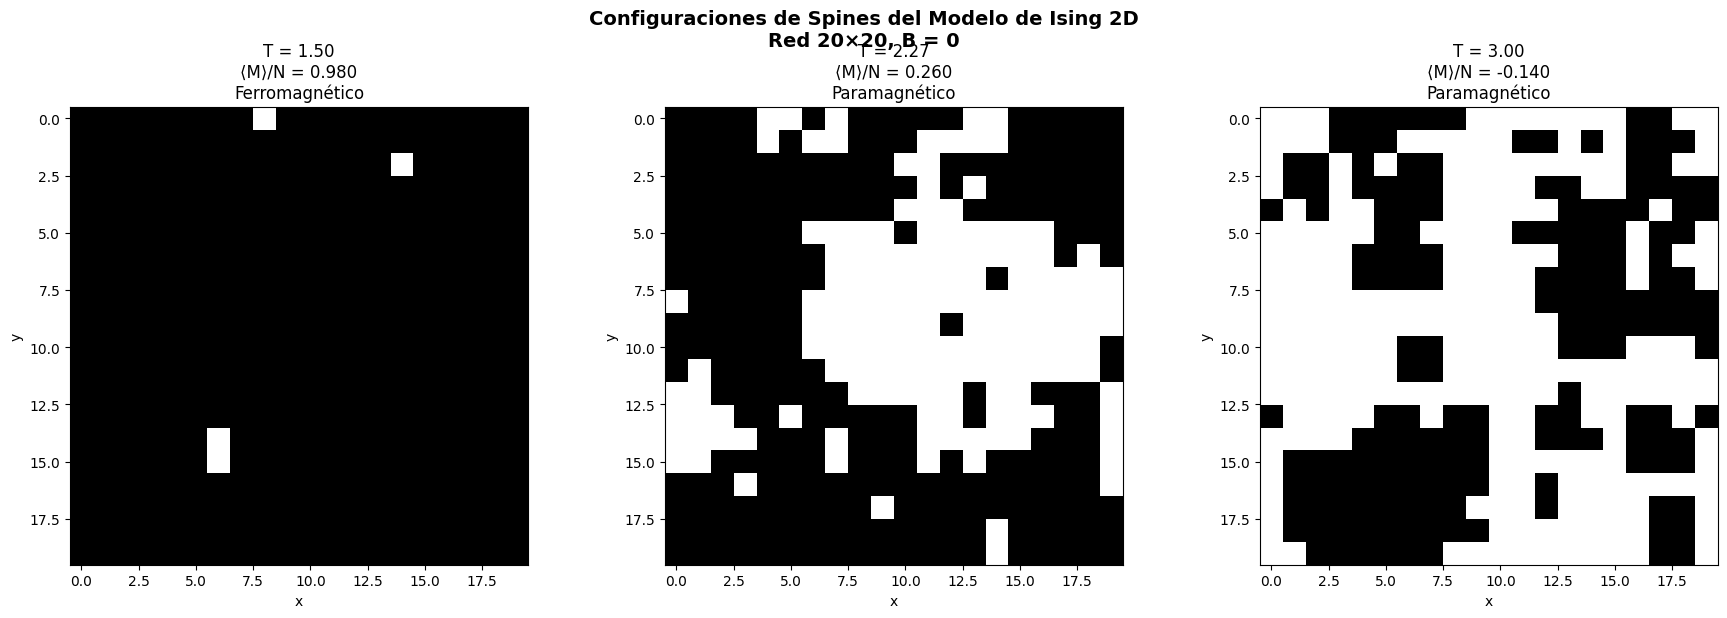

✅ Configuraciones de spines generadas


In [ ]:
# ============================================
# GRÁFICA 4: Visualización de configuraciones de spines
# Para ver el ordenamiento a diferentes temperaturas
# ============================================

def plot_spin_configuration(T, B=0.0, n_eq=5000):
    """Genera y visualiza una configuración de spines"""
    ising = Ising2D(N, J, kB)

    # Equilibrar
    for _ in range(n_eq):
        ising.metropolis_step(T, B)

    # Crear figura
    fig, ax = plt.subplots(figsize=(8, 8))

    # Visualizar spines (↑ blanco, ↓ negro)
    im = ax.imshow(ising.spins, cmap='binary', interpolation='nearest')

    # Calcular magnetización
    M = ising.get_magnetization() / ising.n_spins

    ax.set_title(f'Configuración de Spines\nT = {T:.2f}, B = {B}, ⟨M⟩/N = {M:.3f}',
                fontsize=13, fontweight='bold')
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)

    plt.tight_layout()
    plt.savefig(f'spins_T{T:.1f}_B{B}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return ising.spins, M

# Visualizar para las tres temperaturas a B=0
if 'N' in locals():
    print("Generando configuraciones de spines...")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for idx, T in enumerate(temperatures):
        ising_temp = Ising2D(N, J, kB)
        for _ in range(5000):
            ising_temp.metropolis_step(T, 0.0)

        M = ising_temp.get_magnetization() / ising_temp.n_spins

        ax = axes[idx]
        im = ax.imshow(ising_temp.spins, cmap='binary', interpolation='nearest')
        ax.set_title(f'T = {T:.2f}\n⟨M⟩/N = {M:.3f}\n' +
                    ('Ferromagnético' if T < Tc_exact else 'Paramagnético'),
                    fontsize=12)
        ax.set_xlabel('x')
        ax.set_ylabel('y')

    plt.suptitle('Configuraciones de Spines del Modelo de Ising 2D\n' +
                 f'Red {N}×{N}, B = 0',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('ising_spin_configurations.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Configuraciones de spines generadas")

Nota: 4.5 (entrega tarde)

* ¿porqué considera los vecinos si esto es no interactuante? 
* En la magnetización haces kB = 1, magneton de Bhor 1..., pero al final debe recuperarse el valor en el MKS. La figura no corresponde a la que se pide en el enunciado, 
ya que no se ha recuperado el valor de kB.
* NO analiza las tres temperaturas sugeridas y el campo el Gauss???
* Mucha IA... se dejó llevar con el error en el enunciado... ni cuenta se dió!